# Prototyping Difference Gradient Analysis for MISalign 2.0

In [89]:
# %matplotlib widget
%matplotlib inline

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.colors as colors

from misalign.model.project import MISProjectJSON
from misalign.model.relation import MISRelationRectangular
import misalign.alignment.difference_gradient as dga
import misalign.canvas.canvas_rectangular as cr
import misalign.alignment.difference_rectangular as dr

In [85]:
mis_filepath="../example/project_a/project_a-relations-calibrated.mis.json"
mis_project=MISProjectJSON.load(mis_filepath)
mis_project.find_image_paths(mis_filepath,update=True)
print(mis_project)

A misalign project with:
Images:
    image_a01.jpg
    image_a02.jpg
    image_a03.jpg
    image_a04.jpg
    image_a05.jpg
    image_a06.jpg
    image_a07.jpg
    image_a08.jpg
    image_a09.jpg
    image_a10.jpg
Relations:
    ('image_a01.jpg', 'image_a02.jpg')
    ('image_a02.jpg', 'image_a03.jpg')
    ('image_a03.jpg', 'image_a04.jpg')
    ('image_a04.jpg', 'image_a05.jpg')
    ('image_a05.jpg', 'image_a06.jpg')
    ('image_a06.jpg', 'image_a07.jpg')
    ('image_a07.jpg', 'image_a08.jpg')
    ('image_a08.jpg', 'image_a09.jpg')
    ('image_a09.jpg', 'image_a10.jpg')
Calibration:
    pixel : 600
    length : 1
    length_unit : mm
Project Path:
    ..\example\project_a\project_a-relations-calibrated.mis.json


In [86]:
plt.close('all')

In [219]:
# 2 is fairly well overlapped
# 7 is neat for seeing how physical features effect plot.
# 8 is particularly bad initial alignment and good for visualizing
selected_relation=mis_project.get_relations()[11]
selected_dga_results=dr.difference_gradient_analysis(
        image_a=mis_project.get_image(selected_relation.get_reference()[0]),
        image_b=mis_project.get_image(selected_relation.get_reference()[1]),
        relation=selected_relation,
        strategy=dr.strategy_scaled_grid,
        metric=dr.metric_difference_squared_mean,
        # metric=lambda a,b : dr.metric_combined_simple_norm(a,b,modifier_squared=50),
        strategy_max_size=50,
        strategy_grid_scale=1,
        filter=dr.filter_rgb_gray_mean
        )
print("Initial:",selected_dga_results["initial_offset"],"Optimized:",selected_dga_results["optimized_offset"])

Initial: (853, 134) Optimized: (855, 137)


In [ ]:
dga.plot_grid_difference_gradient_analysis(
        image_a=mis_project.get_image(selected_relation.get_reference()[0]),
        image_b=mis_project.get_image(selected_relation.get_reference()[1]),
        dga_grid_result=selected_dga_results,
    )
plt.show()

0 : ('image_a01.jpg', 'image_a02.jpg') (12, -1088) -> (9, -1086)


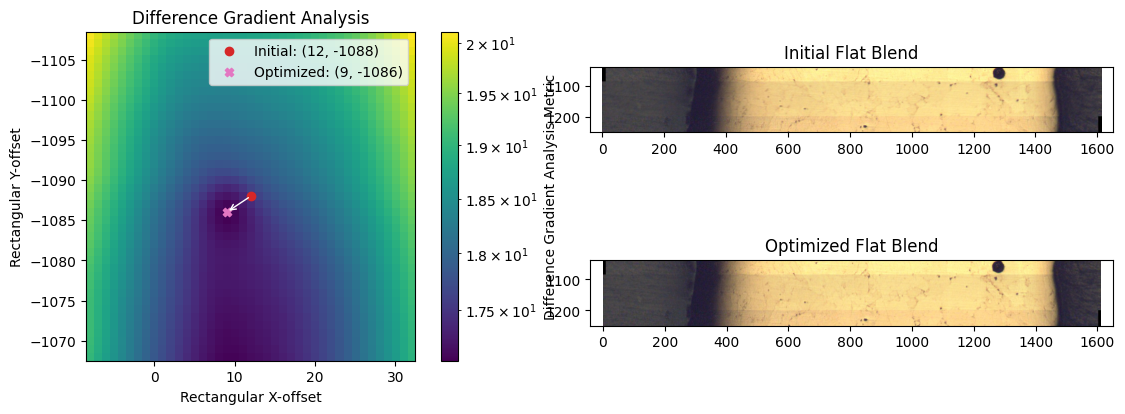

1 : ('image_a02.jpg', 'image_a03.jpg') (8, -1141) -> (8, -1145)


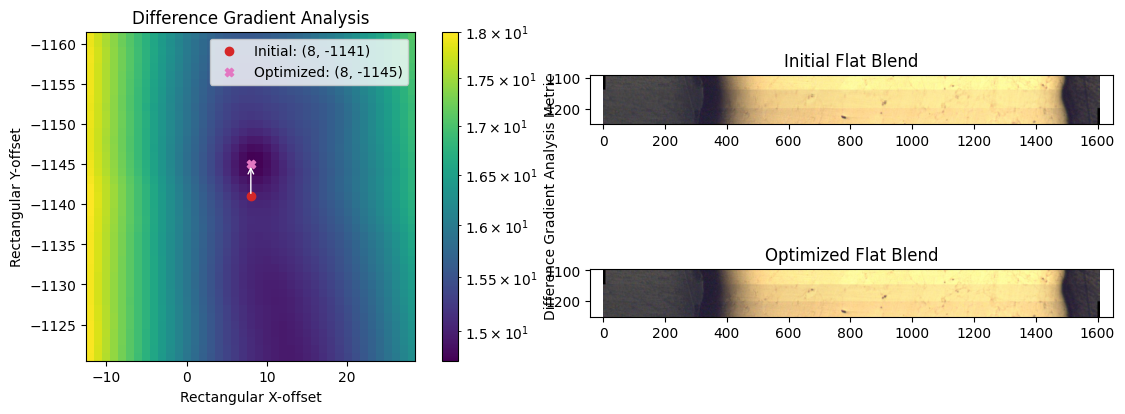

2 : ('image_a03.jpg', 'image_a04.jpg') (-129, -1058) -> (-124, -1060)


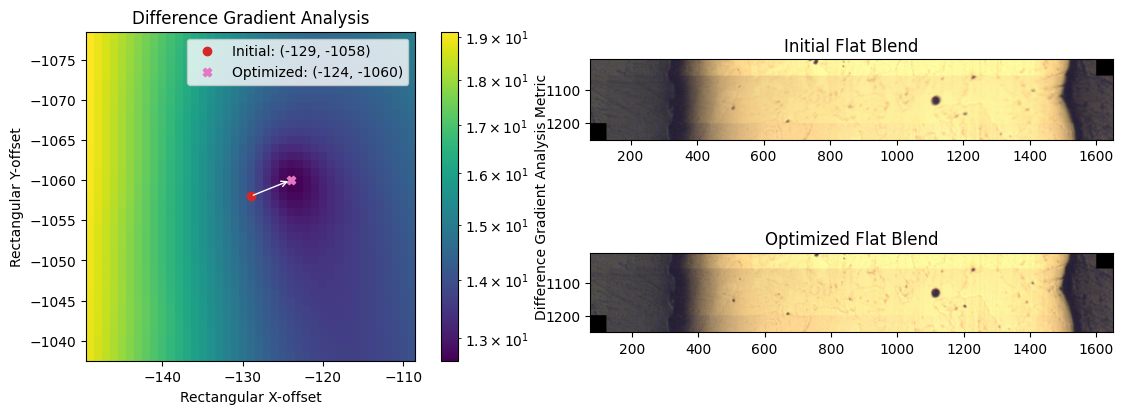

3 : ('image_a04.jpg', 'image_a05.jpg') (11, -943) -> (10, -942)


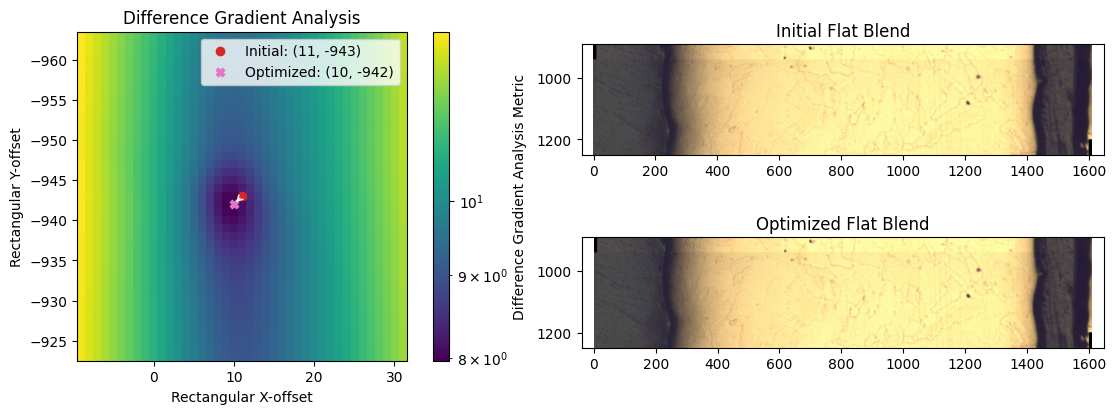

4 : ('image_a05.jpg', 'image_a06.jpg') (5, -860) -> (7, -857)


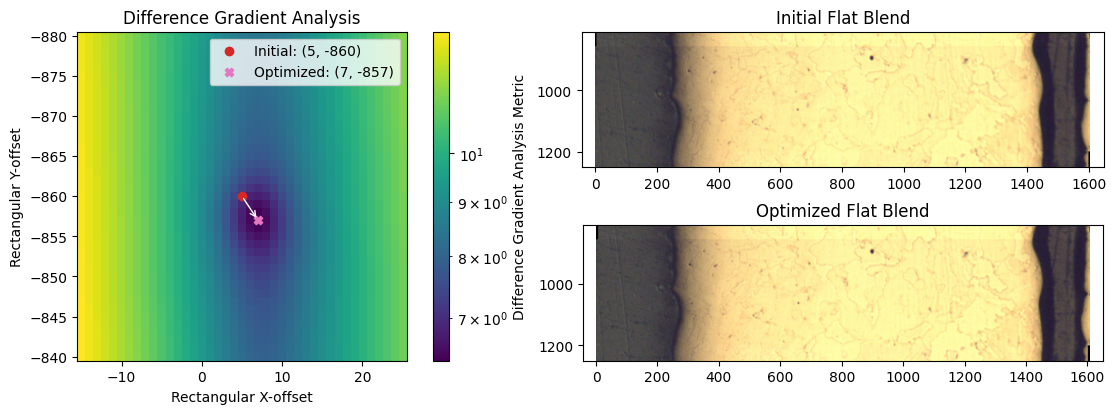

5 : ('image_a06.jpg', 'image_a07.jpg') (10, -990) -> (8, -990)


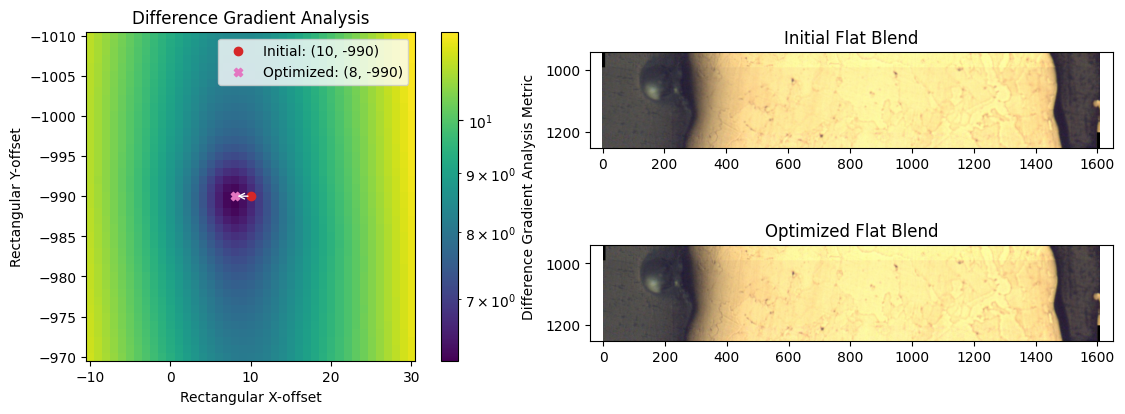

6 : ('image_a07.jpg', 'image_a08.jpg') (9, -1009) -> (8, -1008)


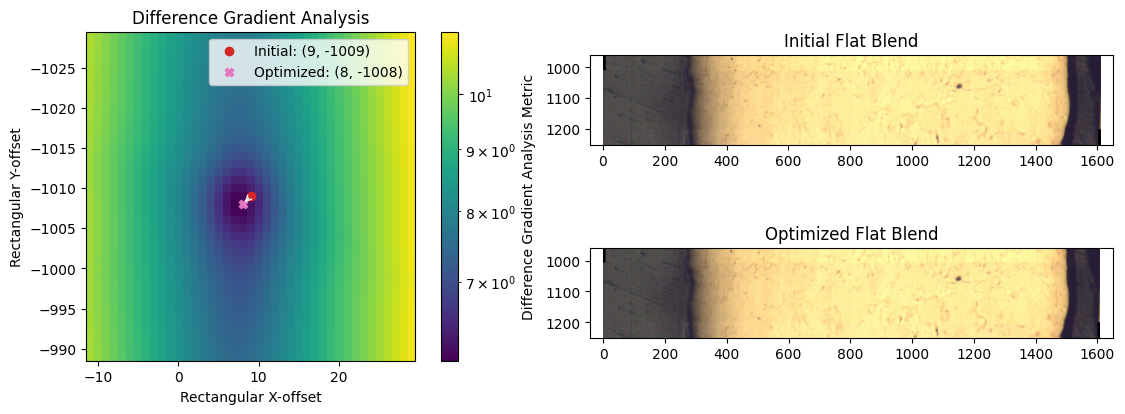

7 : ('image_a08.jpg', 'image_a09.jpg') (9, -939) -> (7, -938)


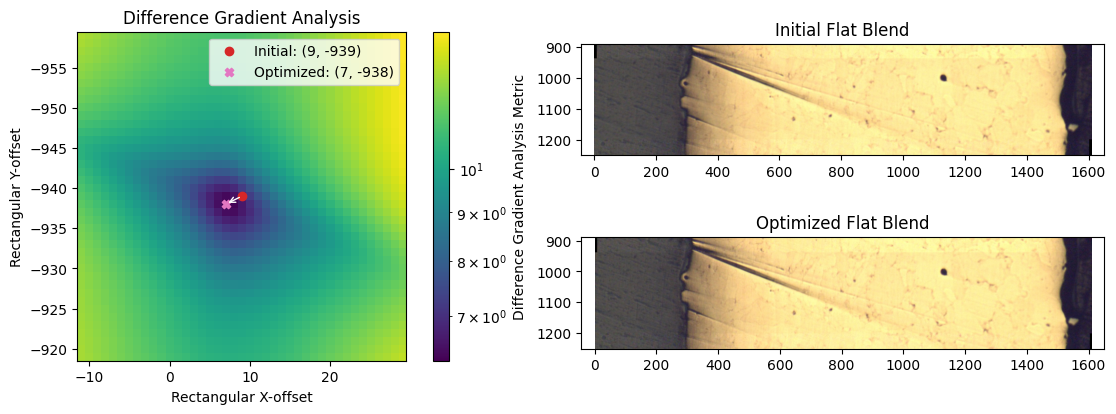

8 : ('image_a09.jpg', 'image_a10.jpg') (3, -722) -> (4, -715)


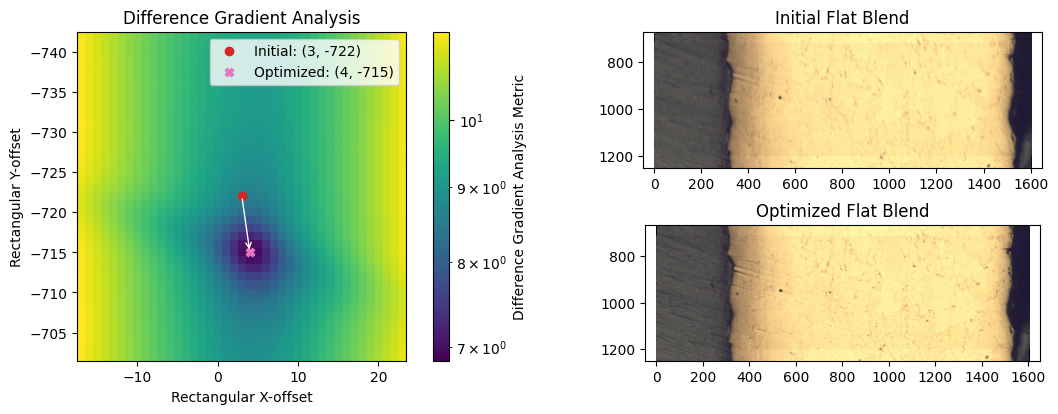

In [7]:
relation_index_results=dict()
for i,relation in enumerate(mis_project.get_relations()):
    dga_results=dr.difference_gradient_analysis(
            image_a=mis_project.get_image(relation.get_reference()[0]),
            image_b=mis_project.get_image(relation.get_reference()[1]),
            relation=relation,
            strategy=dr.strategy_full_grid,
            metric=dr.metric_difference_absolute_mean,
            strategy_max_size=20,
            )
    print(i,":",relation.get_reference(),relation.get_relation('r'),"->",dga_results["optimized_offset"])
    dga.plot_grid_difference_gradient_analysis(
        image_a=mis_project.get_image(relation.get_reference()[0]),
        image_b=mis_project.get_image(relation.get_reference()[1]),
        dga_grid_result=dga_results,
    )
    plt.show()
    

In [ ]:
# [mis_project.set_relation(i,relation) for i,relation in relation_index_results.items()]
# mis_filepath="../example/project_a/project_a-dga_relations-calibrated.mis.json"
# mis_project.save(mis_filepath)

# Comparing Performances

In [8]:
import timeit
import pandas as pd
import seaborn as sns
import math

In [19]:
# 2 is fairly well overlapped
# 8 is extremely well overlapped
performance_relation=mis_project.get_relations()[2]
performance_optimized_relation=(-124, -1060) # for [2]
performance_dga_results=dr.difference_gradient_analysis(
        image_a=mis_project.get_image(performance_relation.get_reference()[0]),
        image_b=mis_project.get_image(performance_relation.get_reference()[1]),
        relation=performance_relation,
        strategy=dr.strategy_scaled_grid,
        metric=dr.metric_difference_squared_mean,
        strategy_max_size=20,
        strategy_grid_scale=1,
        filter=dr.filter_rgb_gray_mean
        )
print("Initial:",performance_dga_results["initial_offset"],"Optimized:",performance_dga_results["optimized_offset"])
def performance_run(kwargs):
    performance_dga_results=dr.difference_gradient_analysis(
        image_a=mis_project.get_image(performance_relation.get_reference()[0]),
        image_b=mis_project.get_image(performance_relation.get_reference()[1]),
        relation=performance_relation,
        **kwargs
        )
    # assert performance_dga_results["optimized_offset"]==performance_optimized_relation # this makes sure that the same result is found
    assert math.dist(performance_dga_results["optimized_offset"],performance_optimized_relation)<2 # this makes sure that the result is identical or neighbor to reference.
def get_run_description(kwargs)->dict:
    return {key:(value.__name__ if hasattr(value,"__name__") else value) for key,value in kwargs.items()}
performance_repeats=5
performance_repeats_long=1
performance_results=list()

Initial: (-129, -1058) Optimized: (-124, -1060)


In [20]:
for size in [20,50]:
    kwargs=dict(
        strategy=dr.strategy_full_grid,
        metric=dr.metric_difference_squared_mean,
        strategy_max_size=size,
        filter=dr.filter_simple
        )
    run_result=get_run_description(kwargs)
    run_result["average_time"]=timeit.timeit(stmt='performance_run(kwargs)',globals = globals(),number=performance_repeats)/performance_repeats
    print(run_result)
    performance_results.append(run_result)

for size in [20,50,100]:
    kwargs=dict(
        strategy=dr.strategy_full_grid,
        metric=dr.metric_difference_squared_mean,
        strategy_max_size=size,
        filter=dr.filter_rgb_gray_mean
        )
    run_result=get_run_description(kwargs)
    run_result["average_time"]=timeit.timeit(stmt='performance_run(kwargs)',globals = globals(),number=performance_repeats)/performance_repeats
    print(run_result)
    performance_results.append(run_result)

{'strategy': 'strategy_full_grid', 'metric': 'metric_difference_squared_mean', 'strategy_max_size': 20, 'filter': 'filter_simple', 'average_time': 2.4298994400000082}
{'strategy': 'strategy_full_grid', 'metric': 'metric_difference_squared_mean', 'strategy_max_size': 50, 'filter': 'filter_simple', 'average_time': 14.74062578000012}
{'strategy': 'strategy_full_grid', 'metric': 'metric_difference_squared_mean', 'strategy_max_size': 20, 'filter': 'filter_rgb_gray_mean', 'average_time': 0.3802674600003229}
{'strategy': 'strategy_full_grid', 'metric': 'metric_difference_squared_mean', 'strategy_max_size': 50, 'filter': 'filter_rgb_gray_mean', 'average_time': 2.708057440000266}
{'strategy': 'strategy_full_grid', 'metric': 'metric_difference_squared_mean', 'strategy_max_size': 100, 'filter': 'filter_rgb_gray_mean', 'average_time': 13.46413618000006}


In [21]:
for size in [20,50]:
    kwargs=dict(
        strategy=dr.strategy_full_grid,
        metric=dr.metric_difference_absolute_mean,
        strategy_max_size=size,
        filter=dr.filter_simple
        )
    run_result=get_run_description(kwargs)
    run_result["average_time"]=timeit.timeit(stmt='performance_run(kwargs)',globals = globals(),number=performance_repeats)/performance_repeats
    print(run_result)
    performance_results.append(run_result)


for size in [20,50,100]:
    kwargs=dict(
        strategy=dr.strategy_full_grid,
        metric=dr.metric_difference_absolute_mean,
        strategy_max_size=size,
        filter=dr.filter_rgb_gray_mean
        )
    run_result=get_run_description(kwargs)
    run_result["average_time"]=timeit.timeit(stmt='performance_run(kwargs)',globals = globals(),number=performance_repeats)/performance_repeats
    print(run_result)
    performance_results.append(run_result)

{'strategy': 'strategy_full_grid', 'metric': 'metric_difference_absolute_mean', 'strategy_max_size': 20, 'filter': 'filter_simple', 'average_time': 1.5197619400001714}
{'strategy': 'strategy_full_grid', 'metric': 'metric_difference_absolute_mean', 'strategy_max_size': 50, 'filter': 'filter_simple', 'average_time': 9.56881693999967}
{'strategy': 'strategy_full_grid', 'metric': 'metric_difference_absolute_mean', 'strategy_max_size': 20, 'filter': 'filter_rgb_gray_mean', 'average_time': 0.40896141999983227}
{'strategy': 'strategy_full_grid', 'metric': 'metric_difference_absolute_mean', 'strategy_max_size': 50, 'filter': 'filter_rgb_gray_mean', 'average_time': 2.330324020000262}
{'strategy': 'strategy_full_grid', 'metric': 'metric_difference_absolute_mean', 'strategy_max_size': 100, 'filter': 'filter_rgb_gray_mean', 'average_time': 9.713946459999715}


In [22]:
for size in [20,50]:
    kwargs=dict(
        strategy=dr.strategy_full_grid,
        metric=dga.metric_combined_balanced,
        strategy_max_size=size,
        filter=dr.filter_rgb_gray_mean
        )
    run_result=get_run_description(kwargs)
    run_result["average_time"]=timeit.timeit(stmt='performance_run(kwargs)',globals = globals(),number=performance_repeats)/performance_repeats
    print(run_result)
    performance_results.append(run_result)

{'strategy': 'strategy_full_grid', 'metric': 'metric_combined_balanced', 'strategy_max_size': 20, 'filter': 'filter_rgb_gray_mean', 'average_time': 1.1628156399994622}
{'strategy': 'strategy_full_grid', 'metric': 'metric_combined_balanced', 'strategy_max_size': 50, 'filter': 'filter_rgb_gray_mean', 'average_time': 7.508747120000043}


In [16]:
def metric_highlow_inverse_norm_test(overlap_a:np.ndarray,overlap_b:np.ndarray,modifier=64)->float:
    """High value when difference of maximum and minimum intensity of overlap region is low > weights against low-feature regions"""
    def metric(overlap):
        return  np.min([1/((np.max(overlap)-np.min(overlap))/modifier),1])
        # variation of 64 > value of 1 > variation of 128 > value of 1/2
    return np.max([metric(overlap_a),metric(overlap_b)])

def metric_custom(overlap_a:np.ndarray,overlap_b:np.ndarray):
    return np.sum([
        dga.metric_difference_max_norm(overlap_a,overlap_b),
        dga.metric_squared_mean_norm(overlap_a,overlap_b)**0.1,
        # dga.metric_highlow_inverse_norm(overlap_a,overlap_b),
        metric_highlow_inverse_norm_test(overlap_a,overlap_b),
    ])

for size in [20,50]:
    kwargs=dict(
        strategy=dga.strategy_full_grid,
        metric=metric_custom,
        strategy_max_size=size,
        filter=dga.filter_rgb_gray
        )
    run_result=get_run_description(kwargs)
    run_result["average_time"]=timeit.timeit(stmt='performance_run(kwargs)',globals = globals(),number=performance_repeats)/performance_repeats
    print(run_result)
    performance_results.append(run_result)

{'strategy': 'strategy_full_grid', 'metric': 'metric_custom', 'strategy_max_size': 20, 'filter': 'filter_rgb_gray', 'average_time': 1.0664923999996971}
{'strategy': 'strategy_full_grid', 'metric': 'metric_custom', 'strategy_max_size': 50, 'filter': 'filter_rgb_gray', 'average_time': 6.409637199999997}


In [ ]:
#TODO add total time(timeit call)/then average time

In [ ]:
df_performance=pd.DataFrame(performance_results)
df_performance["average_time"]=np.round(df_performance["average_time"],2)
df_performance["total_checked"]=(2*df_performance["strategy_max_size"]+1)**2
print(df_performance.to_markdown())

In [ ]:
sns.relplot(
    data=df_performance,
    x='strategy_max_size',
    y='average_time',
    hue='metric',
    style='filter',
    markers=["o","X"],
    kind="line",
    )
sns.relplot(
    data=df_performance,
    x='total_checked',
    y='average_time',
    hue='metric',
    style='filter',
    markers=["o","X"],
    kind="line",
    )

# Full Search

In [1]:
import numpy as np
from matplotlib import pyplot as plt

from misalign.model.project import MISProjectJSON
import misalign.alignment.difference_gradient as dga
import misalign.alignment.difference_rectangular as dr

In [80]:
import pandas as pd
import skimage

import timeit
import logging
from sys import stdout
logging.basicConfig(stream=stdout, level=logging.INFO)

In [170]:
%matplotlib widget
plt.close('all')

In [163]:
mis_filepath="../example/project_a/project_a-relations-calibrated.mis.json"
mis_project=MISProjectJSON.load(mis_filepath)
mis_project.find_image_paths(mis_filepath,update=True)
print(mis_project)

A misalign project with:
Images:
    image_a01.jpg
    image_a02.jpg
    image_a03.jpg
    image_a04.jpg
    image_a05.jpg
    image_a06.jpg
    image_a07.jpg
    image_a08.jpg
    image_a09.jpg
    image_a10.jpg
Relations:
    ('image_a01.jpg', 'image_a02.jpg')
    ('image_a02.jpg', 'image_a03.jpg')
    ('image_a03.jpg', 'image_a04.jpg')
    ('image_a04.jpg', 'image_a05.jpg')
    ('image_a05.jpg', 'image_a06.jpg')
    ('image_a06.jpg', 'image_a07.jpg')
    ('image_a07.jpg', 'image_a08.jpg')
    ('image_a08.jpg', 'image_a09.jpg')
    ('image_a09.jpg', 'image_a10.jpg')
Calibration:
    pixel : 600
    length : 1
    length_unit : mm
Project Path:
    ..\example\project_a\project_a-relations-calibrated.mis.json


In [164]:
def filter_rgb_gray_mean_gaussian(image):
    return skimage.filters.gaussian(dr.filter_rgb_gray_mean(image),sigma=1)
def filter_rgb_gray_mean_dilate(image):
    return skimage.morphology.dilation(dr.filter_rgb_gray_mean(image),skimage.morphology.disk(5))
    # dilation configured to remove debris on imaging system that shows up as small black dots.

In [165]:
full_search_filter=dr.filter_rgb_gray_mean

In [ ]:
#TODO make calibration results more dynamic in accept strategies.
# for relation in mis_project.get_relations()[0:5]:
for relation in [mis_project.get_relations()[0]]:
    image_a=mis_project.get_image(relation.get_reference()[0])
    image_b=mis_project.get_image(relation.get_reference()[1])
    calibration_results_initial=dr.calibrate_metrics_initial(
            image_a=image_a,
            image_b=image_b,
            relation_offset=relation,
            metrics={
                "max":dr.metric_difference_max,
                "absolute":dr.metric_difference_absolute_mean,
                "squared":dr.metric_difference_squared_mean,
                "squared-rooted":lambda a,b:dr.metric_difference_squared_mean(a,b)**0.5,
                "highlow":dr.metric_highlow_inverse,
                # "phase":metric_phase_correlation_distance,
                "pearson":lambda a,b:skimage.measure.pearson_corr_coeff(a,b)[0],
                "mse":skimage.metrics.mean_squared_error,
                "norm rmse":skimage.metrics.normalized_root_mse,
                "nmi":skimage.metrics.normalized_mutual_information,
                # "structural":lambda a,b:skimage.metrics.structural_similarity(a,b,data_range=np.ptp(a)),
                },
            strategies={
                "grid":dr.strategy_full_grid,
                "sparse":dr.strategy_full_search_interpolated_adaptive_grid,
            },
            strategy_kwargs={
                "grid":dict(strategy_max_size=20),
                "sparse":dict(strategy_full_search_progression=[dict(initial_grid_number=40)]),
            },
            filter=full_search_filter,
            )

|                |      grid ptp |     grid min |     grid max |    sparse ptp |   sparse min |    sparse max |
|:---------------|--------------:|-------------:|-------------:|--------------:|-------------:|--------------:|
| max            |  87.6667      |  62          | 149.667      |   180         |  19.3333     |   199.333     |
| absolute       |   3.11962     |  16.6189     |  19.7385     |   137.866     |   5.08617    |   142.952     |
| squared        | 325.993       | 381.769      | 707.762      | 22962.7       |  40.3726     | 23003.1       |
| squared-rooted |   7.06489     |  19.5389     |  26.6038     |   145.314     |   6.35395    |   151.668     |
| highlow        |   3.99603e-05 |   0.00545455 |   0.00549451 |     0.0740293 |   0.00491803 |     0.0789474 |
| pearson        |   0.0332476   |   0.960283   |   0.993531   |     1.90151   |  -0.953686   |     0.947826  |
| mse            | 325.993       | 381.769      | 707.762      | 22962.7       |  40.3726     | 23003.1 

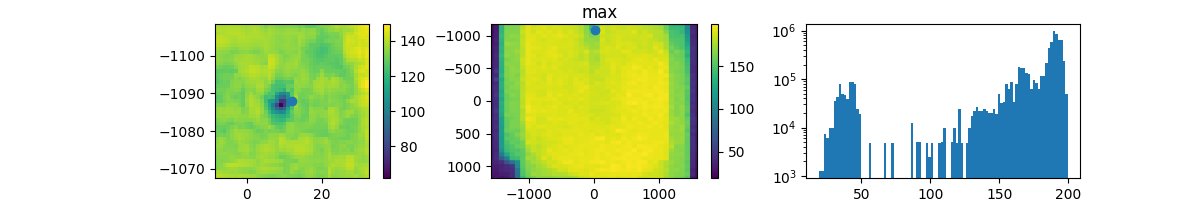

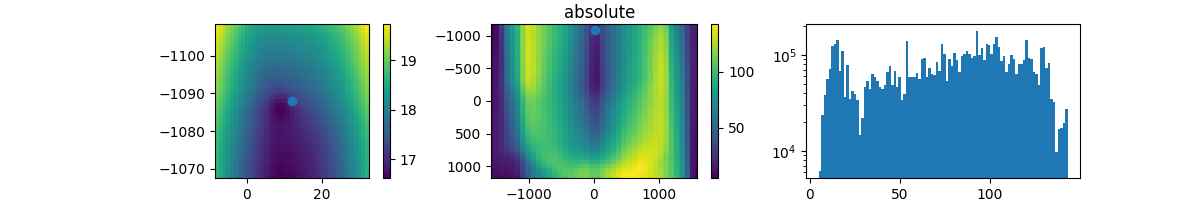

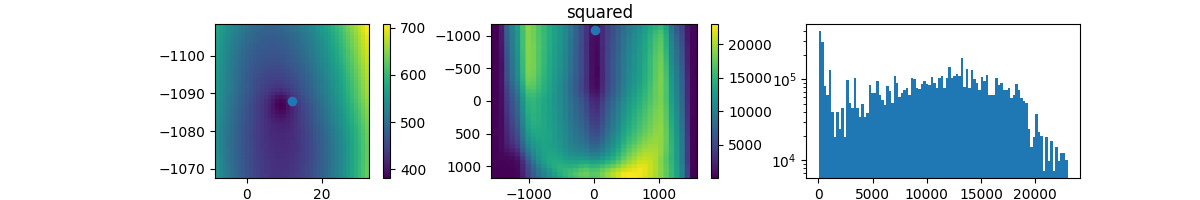

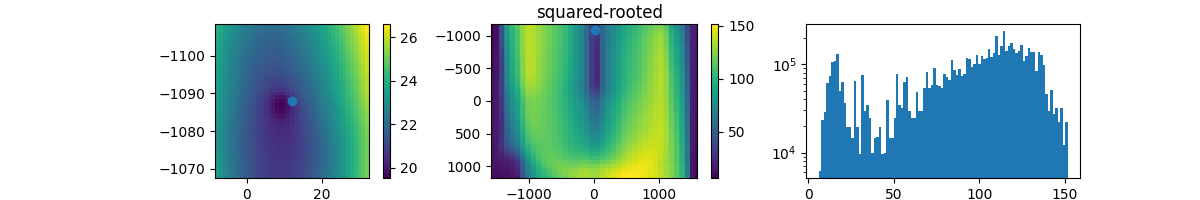

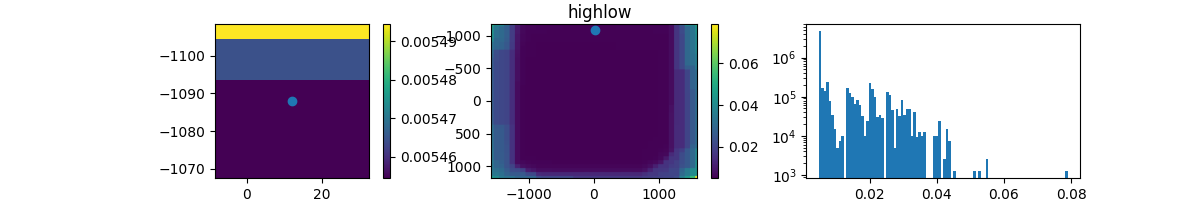

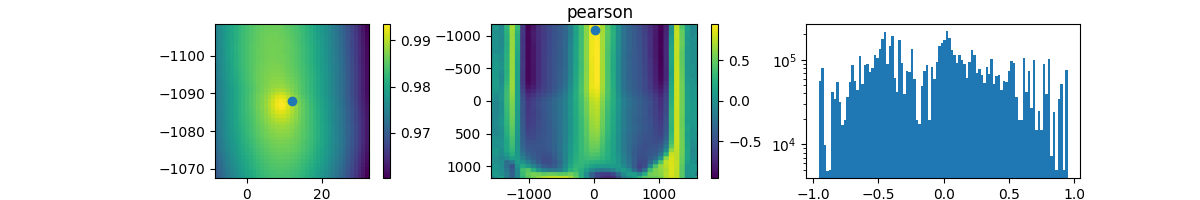

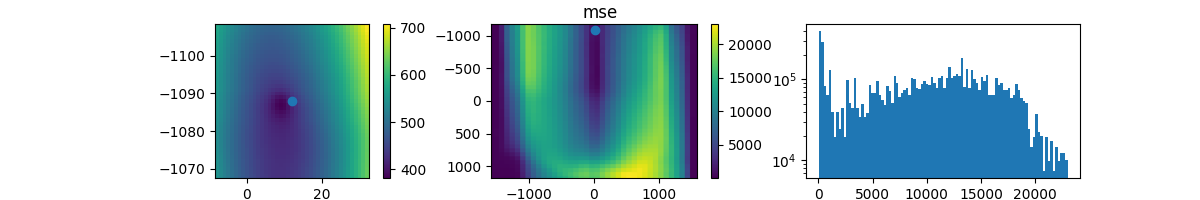

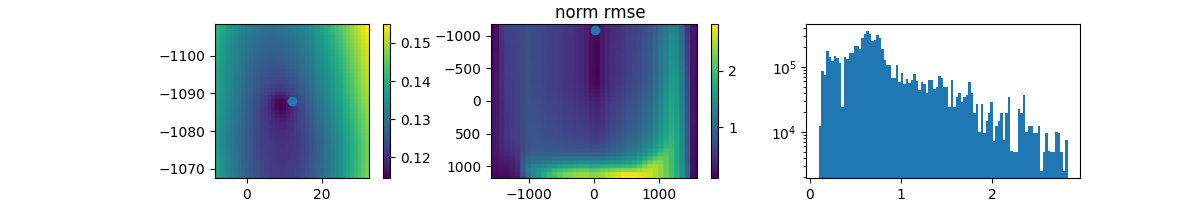

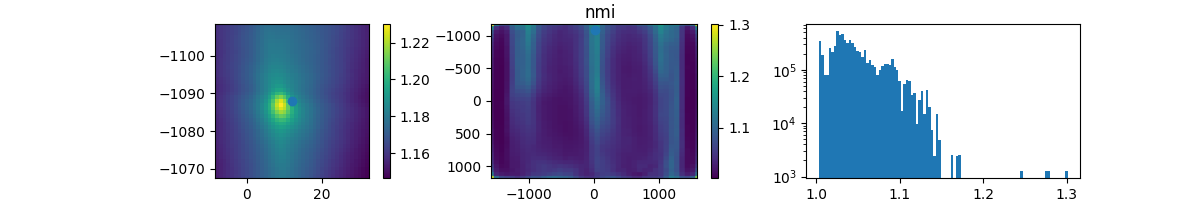

In [171]:
build_summary=dict()
for metric_name,strategies in calibration_results_initial.items():
    fig, axs=plt.subplots(1,len(strategies)+1)
    axs:dict[str,plt.Axes]={strategy_name:ax for strategy_name,ax in zip(list(strategies.keys())+["histogram"],axs)}

    # fig.tight_layout()
    fig.set_figheight(2)
    fig.set_figwidth(4*(len(strategies)+1))
    fig.suptitle(metric_name)

    build_summary[metric_name]=dict()

    for strategy_name,strategy_result in strategies.items():
        if "interp_results" in strategy_result.keys():
            result_key="interp_results"
        else:
            result_key="grid_results"

        build_summary[metric_name][f"{strategy_name} ptp"]=np.ptp(strategy_result[result_key])
        build_summary[metric_name][f"{strategy_name} min"]=np.min(strategy_result[result_key])
        build_summary[metric_name][f"{strategy_name} max"]=np.max(strategy_result[result_key])

        im=axs[strategy_name].imshow(
            X=strategy_result[result_key],
            extent=(
                np.min(strategy_result["grid"][0])-0.5,
                np.max(strategy_result["grid"][0])+0.5,
                np.max(strategy_result["grid"][1])+0.5,
                np.min(strategy_result["grid"][1])-0.5,), #xmin,xmax,ymin,ymax
            )
        axs[strategy_name].scatter(*relation.get_relation('r'))  # ty:ignore[not-iterable]
        plt.colorbar(im)
    
    # histogram generate from whichever strategy is last, assuming sparse full search will be last.
    axs["histogram"].hist(strategy_result[result_key].flatten(),bins=100)
    axs["histogram"].semilogy()

print(pd.DataFrame.from_dict(build_summary,orient='index').to_markdown())

In [ ]:
custom={
    "max":{"modifier":1,"power":1},
    # "absolute":{"modifier":1/100,"power":1},
    "squared-rooted":{"modifier":1,"power":1},
    "highlow":{"modifier":10000,"power":1}
    }

fig, axs=plt.subplots(1,len(strategies))
axs:dict[str,plt.Axes]={strategy_name:ax for strategy_name,ax in zip(strategies.keys(),axs)}
fig.tight_layout()
fig.set_figheight(2)
fig.set_figwidth(4*len(strategies))
fig.suptitle("custom")

custom_grid_results={strategy_name:np.zeros(strategy_results["grid_results"].shape,dtype=np.float64) for strategy_name,strategy_results in strategies.items()}

for metric_name in custom.keys():
    for strategy_name,strategy_results in calibration_results_initial[metric_name].items():

        if "interp_results" in strategy_results.keys():
            result_key="interp_results"
        else:
            result_key="grid_results"
        
        custom_grid_results[strategy_name]+=custom[metric_name]["modifier"]*(strategy_results[result_key]**custom[metric_name]["power"])

for strategy_name,strategy_results in calibration_results_initial[metric_name].items():
    
    im=axs[strategy_name].imshow(
        X=custom_grid_results[strategy_name],
        extent=(np.min(strategy_results["grid"][0])-0.5,
            np.max(strategy_results["grid"][0])+0.5,
            np.max(strategy_results["grid"][1])+0.5,
            np.min(strategy_results["grid"][1])-0.5,), #xmin,xmax,ymin,ymax
            )
    
    if "interp_results" in strategy_results.keys():
            im.set_clim(vmax=np.quantile(custom_grid_results[strategy_name],0.1))
    axs[strategy_name].scatter(*relation.get_relation('r'))  # ty:ignore[not-iterable]
    plt.colorbar(im)
    plt.show()
print(custom)

In [41]:
def metric_custom(overlap_a:np.ndarray,overlap_b:np.ndarray):
    return (
        dr.metric_difference_max(overlap_a,overlap_b)+
        # dr.metric_difference_absolute_mean(overlap_a,overlap_b)+
        (dr.metric_difference_squared_mean(overlap_a,overlap_b)**0.5)+
        10000*dr.metric_highlow_inverse(overlap_a,overlap_b)
        )

In [42]:
# for relation in mis_project.get_relations():
for relation in mis_project.get_relations()[0:5]:
# for relation in [mis_project.get_relations()[0]]:
    dga_results=dr.difference_gradient_analysis(
            image_a=mis_project.get_image(relation.get_reference()[0]),
            image_b=mis_project.get_image(relation.get_reference()[1]),
            relation=relation,
            strategy=dr.strategy_full_grid,
            metric=dr.metric_difference_max,
            strategy_max_size=10,
            filter=dr.filter_rgb_gray_mean
            )
    dga_metric_results=dr.difference_gradient_analysis(
            image_a=mis_project.get_image(relation.get_reference()[0]),
            image_b=mis_project.get_image(relation.get_reference()[1]),
            relation=relation,
            strategy=dr.strategy_full_grid,
            metric=metric_custom,
            strategy_max_size=10,
            filter=full_search_filter,
            )
    # plt.figure()
    # plt.imshow(dga_results["grid_results"])
    optimized_metric=np.min(dga_metric_results["grid_results"])
    print(f"{relation.get_reference()} : {optimized_metric:.2f} : Ref. Offset: {dga_results["optimized_offset"]} Metric Offset: {dga_metric_results["optimized_offset"]}")

('image_c00.tif', 'image_c01.tif') : 140.93 : Ref. Offset: (17, 956) Metric Offset: (17, 956)
('image_c01.tif', 'image_c02.tif') : 156.54 : Ref. Offset: (1, 423) Metric Offset: (1, 423)
('image_c02.tif', 'image_c03.tif') : 186.31 : Ref. Offset: (15, 841) Metric Offset: (15, 841)
('image_c03.tif', 'image_c04.tif') : 170.55 : Ref. Offset: (10, 591) Metric Offset: (10, 591)
('image_c04.tif', 'image_c05.tif') : 135.72 : Ref. Offset: (-459, 387) Metric Offset: (-459, 387)


In [35]:
metric_custom_threshold=190

In [ ]:
plt.close('all')
build_summary=list()
# for full_relation in mis_project.get_relations():
for full_relation in mis_project.get_relations()[0:10]:
# for full_relation in [mis_project.get_relations()[0]]:
    print(full_relation.get_reference())
    optimized_relation=dr.difference_gradient_analysis(
            image_a=mis_project.get_image(full_relation.get_reference()[0]),
            image_b=mis_project.get_image(full_relation.get_reference()[1]),
            relation=full_relation,
            strategy=dr.strategy_full_grid,
            metric=metric_custom,
            strategy_max_size=10,
            filter=dr.filter_rgb_gray_mean
            )["optimized_offset"]
    start_time=timeit.default_timer()
    full_dga_results=dr.difference_gradient_analysis(
            image_a=mis_project.get_image(full_relation.get_reference()[0]),
            image_b=mis_project.get_image(full_relation.get_reference()[1]),
            # relation=full_relation,
            relation=MISRelationRectangular(image_pair=full_relation.get_reference(),rectangular=optimized_relation), #optimized relation
            strategy=dr.strategy_full_search_interpolated_adaptive_grid,
            metric=metric_custom,
            filter=full_search_filter,
            strategy_edge_avoid=200,
            strategy_initial_grid_number=20,
            strategy_metric_comparison=metric_custom_threshold
            )
    end_time=timeit.default_timer()
    print(f"Reference Optimized: {optimized_relation} Full Search DGA Optimized: {full_dga_results["optimized_offset"]} Time: {end_time-start_time:0.1f}s")
    fig, (ax1,ax2)=plt.subplots(1,2,sharex=True,sharey=True)

    ax1.imshow(full_dga_results["grid_results"],
            extent=(np.min(full_dga_results["grid"][0])-0.5,
                    np.max(full_dga_results["grid"][0])+0.5,
                    np.max(full_dga_results["grid"][1])+0.5,
                    np.min(full_dga_results["grid"][1])-0.5,), #xmin,xmax,ymin,ymax)
            vmax=np.quantile(full_dga_results["interp_results"],0.5)
            )

    ax1.scatter(*optimized_relation,marker="X",c='r')
    ax1.scatter(*full_dga_results["optimized_offset"],marker="o",c='pink',alpha=0.5)

    ax2.imshow(full_dga_results["interp_results"],
            extent=(np.min(full_dga_results["grid"][0])-0.5,
                    np.max(full_dga_results["grid"][0])+0.5,
                    np.max(full_dga_results["grid"][1])+0.5,
                    np.min(full_dga_results["grid"][1])-0.5,), #xmin,xmax,ymin,ymax)
            vmax=np.quantile(full_dga_results["interp_results"],0.5)
            )

    ax2.scatter(*optimized_relation,marker="X",c='r')
    ax2.scatter(*full_dga_results["optimized_offset"],marker="o",c='pink',alpha=0.5)

    fig.set_figwidth(12)
    plt.show()
    build_summary.append({
        "reference":full_relation.get_reference(),
        "total_checked":np.sum(~np.isnan(full_dga_results["grid_results"])),
        "total_time":round(end_time-start_time,1),
        "reference_offset":optimized_relation,
        "optimized_offset":full_dga_results["optimized_offset"],
        "optimized_metric":round(np.nanmin(full_dga_results["grid_results"]),2),
        })
print(pd.DataFrame(build_summary).to_markdown())

In [ ]:
print(pd.DataFrame(build_summary).to_markdown())

In [44]:
plt.close('all')

In [45]:
from matplotlib.patches import Rectangle

Reference Optimized: (4, -715) Full Search DGA Optimized: (4, -715) Time: 19.7s


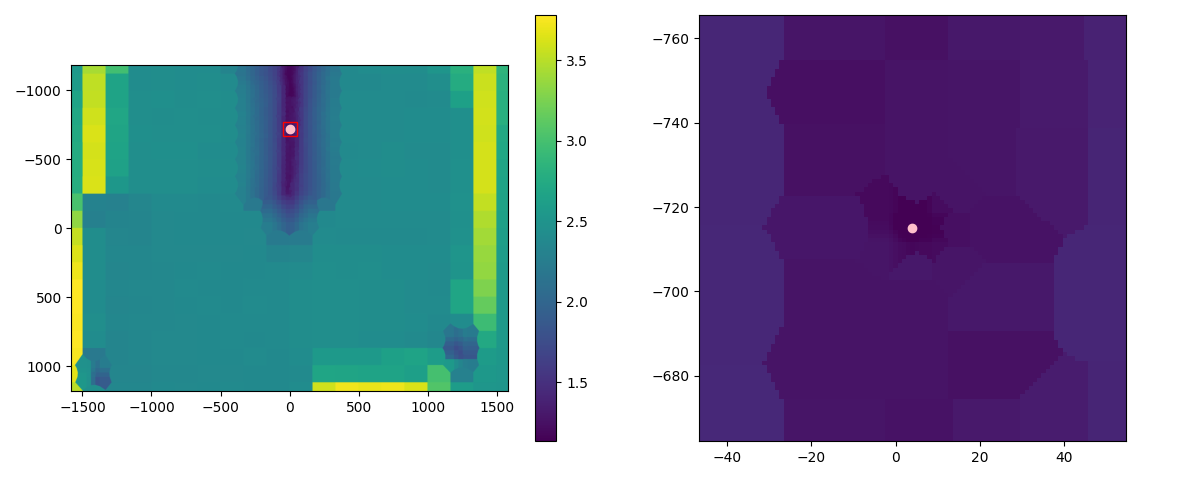

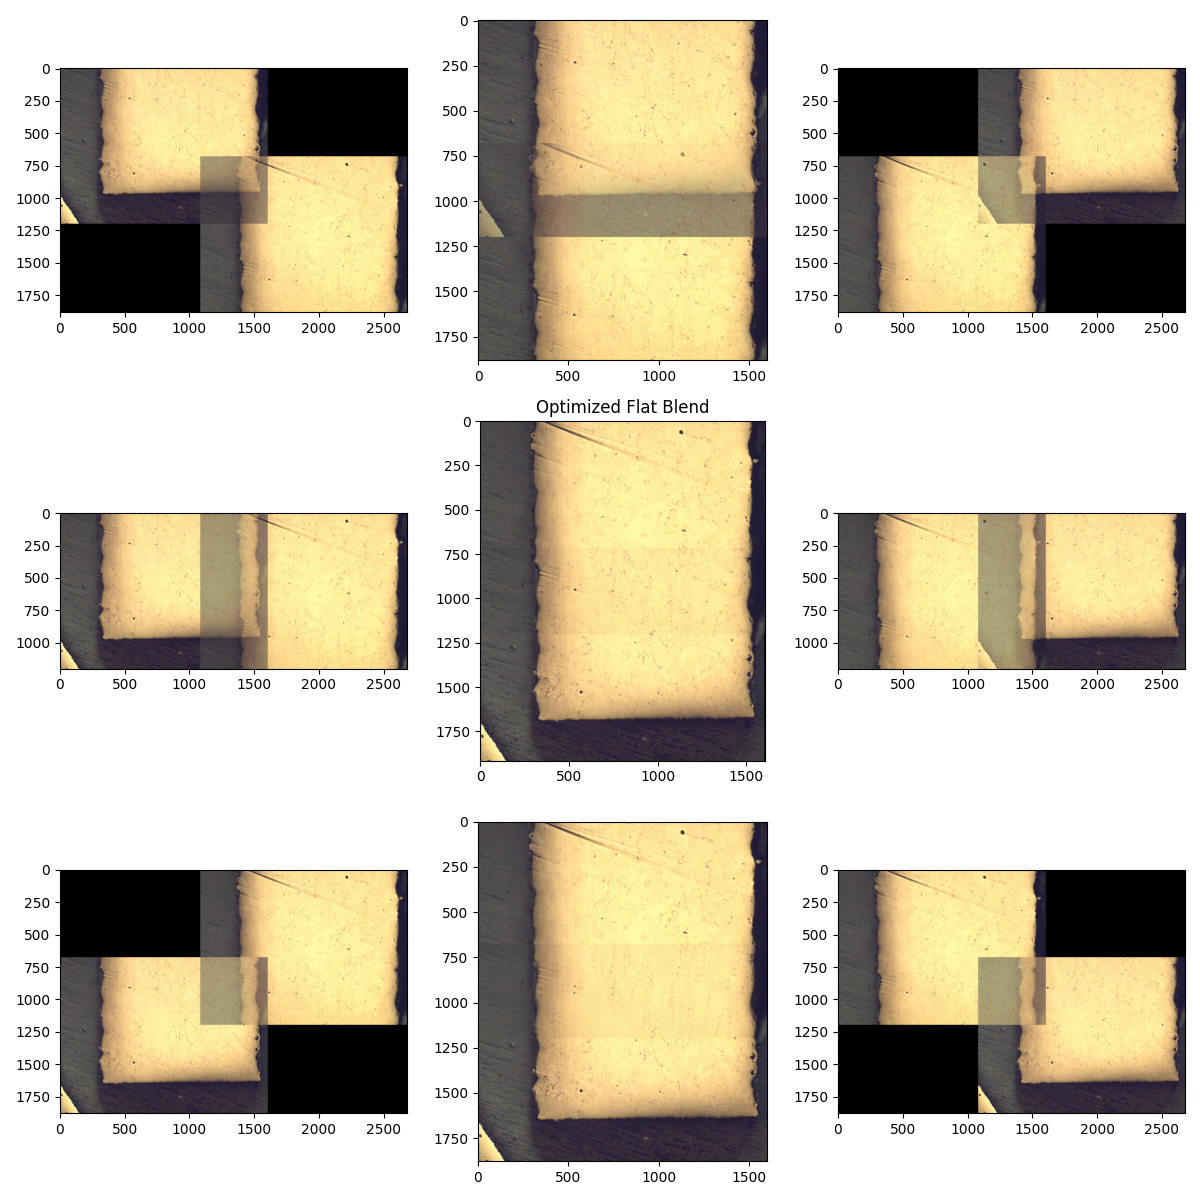

In [46]:
print(f"Reference Optimized: {optimized_relation} Full Search DGA Optimized: {full_dga_results["optimized_offset"]} Time: {end_time-start_time:0.1f}s")
fig1,(ax1,ax2)=plt.subplots(nrows=1,ncols=2)
ax1:plt.Axes
ax2:plt.Axes

focus=101

im1=ax1.imshow(
    X=full_dga_results["interp_results"],
    extent=(np.min(full_dga_results["grid"][0])-0.5,
            np.max(full_dga_results["grid"][0])+0.5,
            np.max(full_dga_results["grid"][1])+0.5,
            np.min(full_dga_results["grid"][1])-0.5,) #xmin,xmax,ymin,ymax)
    )
cb1=plt.colorbar(mappable=im1)
# ax1.scatter(*optimized_relation,marker="X",c='r')
ax1.scatter(*full_dga_results["optimized_offset"],marker="o",c='pink')

ax1.add_artist(
    Rectangle(
        xy=(optimized_relation[0]-focus/2,optimized_relation[1]-focus/2),
        width=focus,
        height=focus,facecolor="none", edgecolor='r'),
    )

im2=ax2.imshow(
    X=full_dga_results["interp_results"],
    extent=(np.min(full_dga_results["grid"][0])-0.5,
            np.max(full_dga_results["grid"][0])+0.5,
            np.max(full_dga_results["grid"][1])+0.5,
            np.min(full_dga_results["grid"][1])-0.5,) #xmin,xmax,ymin,ymax)
    )
# cb2=plt.colorbar(mappable=im2)
# ax2.scatter(*optimized_relation,marker="X",c='r')
ax2.scatter(*full_dga_results["optimized_offset"],marker="o",c='pink')
ax2.set_xlim(left=optimized_relation[0]-focus/2,right=optimized_relation[0]+focus/2)
ax2.set_ylim(top=optimized_relation[1]-focus/2,bottom=optimized_relation[1]+focus/2)

fig1.set_figwidth(12)
plt.tight_layout()
plt.show()

inset=500

mosaic=[["tl","tc","tr"],["ml","mc","mr"],["bl","bc","br"]]
fig2,axs=plt.subplot_mosaic(mosaic=mosaic) # top/middle/bottom - left/right/center

for row in mosaic:
    for position in row:
        if position=="mc":
            offset=full_dga_results["optimized_offset"]
        else:
            match position[0]:
                case "t":
                    y_index=-inset
                case "m":
                    y_index=int(full_dga_results["grid_results"].shape[0]/2)
                case "b":
                    y_index=+inset
            match position[1]:
                case "l":
                    x_index=-inset
                case "c":
                    x_index=int(full_dga_results["grid_results"].shape[1]/2)
                case "r":
                    x_index=inset
            offset=tuple(full_dga_results["grid"][:,y_index,x_index].tolist())
            ax1.scatter(offset[0],offset[1],marker="s",c="k")
        # print(offset)
        plt.sca(axs[position])
        if position=="mc":
            plt.title("Optimized Flat Blend")
        dga.plot_rectangular_pair(
            image_a=mis_project.get_image(full_relation.get_reference()[0]),
            image_b=mis_project.get_image(full_relation.get_reference()[1]),
            relation=offset,
            weight=cr.weight_flat,
            focus_overlap=False,
            )
fig2.set_figwidth(12)
fig2.set_figheight(12)
plt.tight_layout()
plt.show()


# Phase Correlation Test

In [1]:
import math
import logging
import timeit

import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import skimage

from misalign.model.project import MISProjectJSON
import misalign.alignment.difference_gradient as dga
import misalign.alignment.difference_rectangular as dr

In [3]:
mis_filepath="../example/project_b/project_b-relations-calibrated.mis.json"
mis_project=MISProjectJSON.load(mis_filepath)
mis_project.find_image_paths(mis_filepath,update=True)

# phase_filter=dr.filter_rgb_gray_mean
phase_filter=dr.modifier_filter_scharr_edge(filter=dr.filter_rgb_gray_mean)

relation=mis_project.get_relations()[11]

image_a=mis_project.get_image(relation.get_reference()[0])
image_b=mis_project.get_image(relation.get_reference()[1])

reference_offset:tuple[int,int]=relation.get_relation('r')  # ty:ignore[invalid-assignment]
optimized_offset:tuple[int,int]=dr.difference_gradient_analysis(
        image_a=image_a,
        image_b=image_b,
        relation=relation,
        strategy=dr.strategy_full_grid,
        metric=dr.metric_difference_max,
        strategy_max_size=10,
        filter=dr.filter_rgb_gray_mean
        )["optimized_offset"]
print("Optimized:",optimized_offset,"Reference:",reference_offset)

Optimized: (843, 137) Reference: (853, 134)


In [4]:
print(dr.predict_phase_cross_correlation(
    array_a=phase_filter(image_a),
    array_b=phase_filter(image_b),
    offset_ab=optimized_offset,
))

print(dr.predict_phase_cross_correlation(
    array_a=phase_filter(image_a),
    array_b=phase_filter(image_b),
    offset_ab=reference_offset,
))

{'offset': (855, 138), 'shift': array([ -1., -12.], dtype=float32), 'error': np.float32(1.0), 'phasediff': np.float32(1.0446888e-08)}
{'offset': (855, 138), 'shift': array([-4., -2.], dtype=float32), 'error': np.float32(1.0), 'phasediff': np.float32(7.907751e-09)}


In [5]:
def metric_phase_correlation_distance(
        overlap_a:np.ndarray,
        overlap_b:np.ndarray,
    ):
    shift_yx,error,phasediff=skimage.registration.phase_cross_correlation(
        reference_image=overlap_a,
        moving_image=overlap_b,
        disambiguate=True)
    return np.sqrt(np.sum(np.square(shift_yx)))

phase_correlation_results=dr.strategy_full_search_prediction_grid(
    array_a=phase_filter(image_a),
    array_b=phase_filter(image_b),
    # metric=dr.metric_difference_squared_mean,
    metric=lambda a,b:1-skimage.measure.pearson_corr_coeff(a,b)[0],
    initial_offset=optimized_offset,
    )
print("Manual Optimized:",optimized_offset,"Phase Correlation Optimized",phase_correlation_results["optimized_offset"])
# display(phase_correlation_results)
# pd.DataFrame({key:phase_correlation_results[key] for key in ['offsets_reduced','offsets_metric','offsets_metric_norm','offsets_phase_distance','offsets_phase_distance_norm','offsets_combined_norm']})
# print(pd.DataFrame({key:phase_correlation_results[key] for key in ['offsets_searched','offsets_found','reference_comparison','grid_results']}).to_markdown())

Manual Optimized: (843, 137) Phase Correlation Optimized (855, 138)


# Full Search - Phase Cross Correlation Predictions on a Sparse Grid

In [3]:
# projects a-d
mis_filepath="../example/project_a/project_a-relations-calibrated.mis.json"
# mis_filepath="../example/project_b/project_b-relations-calibrated.mis.json"
# mis_filepath="../example/project_c/project_c-relations-calibrated.mis.json"
# mis_filepath="../example/project_d/project_d-relations-calibrated.mis.json"
mis_project=MISProjectJSON.load(mis_filepath)
mis_project.find_image_paths(mis_filepath,update=True)

# full_search_phase_filter=dr.filter_rgb_gray_mean
downsample=1
# full_search_phase_filter=lambda image:skimage.filters.scharr(dr.filter_rgb_gray_mean(image))
full_search_phase_filter=dr.modifier_filter_scharr_edge(dr.filter_rgb_gray_mean)
reference_filter=dr.filter_rgb_gray_mean

In [ ]:
# project e 2 and 8
# mis_filepath="../example/project_e/project_e-2-rel-cal.mis.json"
mis_filepath="../example/project_e/project_e-8-rel-cal.mis.json"
mis_project=MISProjectJSON.load(mis_filepath)
mis_project.find_image_paths(mis_filepath,update=True)

# full_search_phase_filter=dr.filter_rgb_gray_mean
downsample=1
# full_search_phase_filter=lambda image:skimage.filters.median(dr.filter_simple(image)[:1672],footprint=skimage.morphology.disk(2))
full_search_phase_filter=\
    dr.modifier_filter_median_disk(radius=2,filter=\
    dr.modifier_filter_simple_crop(bottom=1672,filter=\
    dr.filter_simple
    ),)
# reference_filter=lambda image:dr.filter_simple(image)[:1672]
reference_filter=dr.modifier_filter_simple_crop(filter=dr.filter_simple,bottom=1672)


In [6]:
# project f
mis_filepath="../example/project_f/project_f-relations-calibrated.mis.json"
mis_project=MISProjectJSON.load(mis_filepath)
mis_project.find_image_paths(mis_filepath,update=True)

# full_search_phase_filter=dr.filter_rgb_gray_mean
downsample=10
full_search_phase_filter=\
        dr.modifier_filter_median_disk(radius=2,filter=\
        dr.modifier_filter_simple_crop(bottom=4096,right=4096,filter=\
        dr.filter_simple,
        ),)
# reference_filter=lambda image:dr.filter_simple(image)[:4096,:4096]
reference_filter=dr.modifier_filter_simple_crop(filter=dr.filter_simple,bottom=4096,right=4096)

In [ ]:
plt.close('all')
build_summary=list()
# for full_relation in mis_project.get_relations():
for full_relation in mis_project.get_relations()[0:5]:
# for full_relation in [mis_project.get_relations()[11]]:
    print(full_relation.get_reference())
    optimized_offset=dr.difference_gradient_analysis(
            image_a=mis_project.get_image(full_relation.get_reference()[0]),
            image_b=mis_project.get_image(full_relation.get_reference()[1]),
            relation=full_relation,
            strategy=dr.strategy_full_grid,
            metric=dr.metric_difference_max,
            strategy_max_size=10,
            filter=reference_filter
            )["optimized_offset"]
    start_time=timeit.default_timer()
    # full_dga_results=dr.difference_gradient_analysis(
    #         image_a=mis_project.get_image(full_relation.get_reference()[0]),
    #         image_b=mis_project.get_image(full_relation.get_reference()[1]),
    #         relation=None,
    #         # relation=MISRelationRectangular(image_pair=full_relation.get_reference(),rectangular=optimized_relation), #optimized relation
    #         strategy=strategy_full_search_phase_cross_correlation_grid,
    #         # metric=dr.metric_difference_squared_mean,
    #         metric=lambda a,b:1-skimage.measure.pearson_corr_coeff(a,b)[0],
    #         filter=full_search_phase_filter,
    #         strategy_max_size=9
    #         )
    
    full_dga_results=dr.difference_gradient_analysis(
            image_a=mis_project.get_image(full_relation.get_reference()[0]),
            image_b=mis_project.get_image(full_relation.get_reference()[1]),
            relation=None,
            # relation=MISRelationRectangular(image_pair=full_relation.get_reference(),rectangular=optimized_relation), #optimized relation
            strategy=dr.strategy_full_search_prediction_grid,
            # metric=dr.metric_difference_squared_mean,
            metric=lambda a,b:1-skimage.measure.pearson_corr_coeff(a,b)[0],
            filter=full_search_phase_filter,
            strategy_initial_grid_number=9,
            strategy_downsample=downsample
            )
    end_time=timeit.default_timer()
    print(f"Reference Optimized: {optimized_offset} Full Search DGA Optimized: {full_dga_results["optimized_offset"]} Time: {end_time-start_time:0.1f}s")


    search_offsets=np.array(full_dga_results["offsets_searched"])
    found_offsets=full_dga_results["offsets_predicted"]
    reduced_offsets=np.asarray(full_dga_results["offsets_reduced"])
    fig, (ax)=plt.subplots(1,1,)
    fig.set_figheight(3)
    fig.set_layout_engine('constrained')
    for i,offset in enumerate(found_offsets):
        ax.annotate("", xytext=search_offsets[i], xy=offset,
                arrowprops=dict(arrowstyle="->",alpha=0.5),)
    ax.yaxis.set_inverted(True)
    ax.scatter(search_offsets[:,0],search_offsets[:,1],marker='s',c='k',alpha=0.5,label="Search Offsets",zorder=0)
    combined_scatter=plt.scatter(reduced_offsets[:,0],reduced_offsets[:,1],c=full_dga_results["offsets_metric"],label="Search Results",zorder=1)
    plt.colorbar(combined_scatter)
    ax.scatter(*np.array(optimized_offset),marker='x', c='r',zorder=10,label="Reference Optimized")#(1/downsample)*()
    ax.scatter(*full_dga_results["optimized_offset"],marker='D', facecolors='none', edgecolors='r',zorder=11,label="Phase Optimized")
    fig.legend(loc="outside right")
    ax.set_aspect(1)
    plt.show()

    build_summary.append({
        "reference":full_relation.get_reference(),
        "total_checked":len(full_dga_results["offsets_searched"]),
        "total_time":round(end_time-start_time,1),
        "reference_offset":optimized_offset,
        "optimized_offset":full_dga_results["optimized_offset"],
        "optimized_metric":round(np.nanmin(full_dga_results["offsets_metric"]),3),
        })
print(pd.DataFrame(build_summary).to_markdown())

In [ ]:
print(pd.DataFrame(build_summary).to_markdown())

# Prototyping Gradient Descent

In [ ]:

def strategy_local_minima_grid(
        array_a:np.ndarray,
        array_b:np.ndarray,
        metric:dr.Callable[[np.ndarray,np.ndarray],float],
        initial_offset:tuple[int,int],
        strategy_max_size:int=20,
        strategy_max_steps:int=20,
        strategy_edge_avoid=20,
        strategy_footprint=None,
        strategy_footprint_shape=(3,3)
        )->dict:
    """
    Gridded local minimization descent search strategy for difference gradient alignment.
    
    Parameters
    ----------
    array_a : np.ndarray
        Numpy array of image a.
        Note: Unsigned integer arrays may underflow and should not be used.
    array_b : np.ndarray
        Numpy array of image b.
        Note: Unsigned integer arrays may underflow and should not be used.
    initial_offset : tuple[int,int]
        An initial estimate for the vector from the top left corner of image a to the top left corner of image b.
        In (x,y) order.
        Example: image b's top left corner is at image a's bottom right corner: `offset=(-width_a,-height_a)`=
    strategy_max_size : int
        Maximum number of steps to check on each side of initial offset or `20` by default.
        Example: `...=5` means an 11x11 set of offsets could be searched.
    metric : Callable[[np.ndarray,np.ndarray],float]
        Function that takes two numpy arrays and returns a value describing some aspect of them or `metric_difference_squared_mean` by default.
        Example: Function which takes the difference of the overlap regions and then squares it and gets the mean value.

    Returns
    -------
    strategy_results : dict
        Dictionary with results of sparse grid search.
        `grid` : np.ndarray
            Offsets that were searched.
        `grid_results` : np.ndarray
            Metric value at matching offset in `grid`.
        `optimized_offset` : tuple[int,int]
            Optimized offset based on minimum in metric value.
        `initial_offset` : tuple[int,int]
            Initial offset provided to strategy.
    """
    
    # Calculate search region boundaries
    x_min: int=np.max([-array_b.shape[1]+1+strategy_edge_avoid,initial_offset[0]-strategy_max_size])
    x_max: int=np.min([array_a.shape[1]-strategy_edge_avoid,initial_offset[0]+strategy_max_size])
    y_min: int=np.max([-array_b.shape[0]+1+strategy_edge_avoid,initial_offset[1]-strategy_max_size])
    y_max: int=np.min([array_a.shape[0]-strategy_edge_avoid,initial_offset[1]+strategy_max_size])

    # Create grid over full search space
    grid: np.ndarray=np.stack(
        arrays=np.meshgrid(
            np.arange(x_min,x_max+1,),
            np.arange(y_min,y_max+1,)
            )
        ).astype(int)
    
    # Setup nan-filled results grid
    grid_results=np.full(grid[0].shape,np.nan)

    # Check initial point in grid
    grid_results[np.all((grid[0]==initial_offset[0],grid[1]==initial_offset[1]),axis=0)]=dr.overlap_evaluate(array_a,array_b,
            offset_ab=initial_offset,
            metric=metric)

    # Setup function for checking based on index.
    def check_offset(iy,ix):
        grid_results[iy,ix]=dr.overlap_evaluate(
                    array_a=array_a,
                    array_b=array_b,
                    offset_ab=grid[:,iy,ix],
                    metric=metric)
    # Setup function for checking values around index.
    if strategy_footprint is None:
        footprint_array:np.ndarray=np.ones(shape=strategy_footprint_shape)
    else:
        footprint_array:np.ndarray=strategy_footprint
    def check_near(iy,ix):
        ix_positions,iy_positions=np.meshgrid(
            np.arange(ix-np.floor_divide(footprint_array.shape[0],2),ix+np.floor_divide(footprint_array.shape[0],2)+1),
            np.arange(iy-np.floor_divide(footprint_array.shape[1],2),iy+np.floor_divide(footprint_array.shape[1],2)+1))
        x_valid=np.logical_and(ix_positions>=0, ix_positions<grid_results.shape[0])
        y_valid=np.logical_and(iy_positions>=0, iy_positions<grid_results.shape[1])
        valid=np.all([x_valid,y_valid,footprint_array],axis=0)
        
        any_unsearched=True
        for ix,iy in zip(ix_positions[valid].flatten(),iy_positions[valid].flatten()):
            if np.isnan(grid_results[iy,ix]):
                check_offset(iy,ix)
                any_unsearched=False
        return any_unsearched
    
    for i in range(strategy_max_steps):
        iy,ix=np.unravel_index(np.nanargmin(grid_results), grid_results.shape)
        if check_near(iy,ix):
            break


    
    # Get indeces of optimized offset
    optimized_location:tuple=np.unravel_index(np.nanargmin(grid_results), grid_results.shape)
    # Get optimized offset
    optimized_offset:tuple[int,int]=tuple(grid[:,optimized_location[0],optimized_location[1]].tolist())
    return {
        "grid":grid,
        "grid_results":grid_results,
        "optimized_offset":optimized_offset,
        "initial_offset":initial_offset
        }

In [2]:
mis_filepath="../example/project_a/project_a-relations-calibrated.mis.json"
# mis_filepath="../example/project_b/project_b-relations-calibrated.mis.json"
# mis_filepath="../example/project_c/project_c-relations-calibrated.mis.json"
# mis_filepath="../example/project_d/project_d-relations-calibrated.mis.json"
mis_project=MISProjectJSON.load(mis_filepath)
mis_project.find_image_paths(mis_filepath,update=True)
print(mis_project)

A misalign project with:
Images:
    image_a01.jpg
    image_a02.jpg
    image_a03.jpg
    image_a04.jpg
    image_a05.jpg
    image_a06.jpg
    image_a07.jpg
    image_a08.jpg
    image_a09.jpg
    image_a10.jpg
Relations:
    ('image_a01.jpg', 'image_a02.jpg')
    ('image_a02.jpg', 'image_a03.jpg')
    ('image_a03.jpg', 'image_a04.jpg')
    ('image_a04.jpg', 'image_a05.jpg')
    ('image_a05.jpg', 'image_a06.jpg')
    ('image_a06.jpg', 'image_a07.jpg')
    ('image_a07.jpg', 'image_a08.jpg')
    ('image_a08.jpg', 'image_a09.jpg')
    ('image_a09.jpg', 'image_a10.jpg')
Calibration:
    pixel : 600
    length : 1
    length_unit : mm
Project Path:
    ..\example\project_a\project_a-relations-calibrated.mis.json


In [21]:

selected_relation=mis_project.get_relations()[8]
selected_dga_results=dr.difference_gradient_analysis(
        image_a=mis_project.get_image(selected_relation.get_reference()[0]),
        image_b=mis_project.get_image(selected_relation.get_reference()[1]),
        relation=selected_relation,
        strategy=dr.strategy_local_minima_grid,
        # metric=dr.metric_difference_squared_mean,
        metric=dr.metric_difference_max,
        strategy_grid_scale=1,
        strategy_max_size=10,
        # strategy_footprint_shape=(7,7),
        strategy_footprint=skimage.morphology.disk(radius=2),
        filter=dr.filter_rgb_gray_mean
        )
print("Initial:",selected_dga_results["initial_offset"],"Optimized:",selected_dga_results["optimized_offset"])
# selected_dga_results

Initial: (3, -722) Optimized: (4, -715)


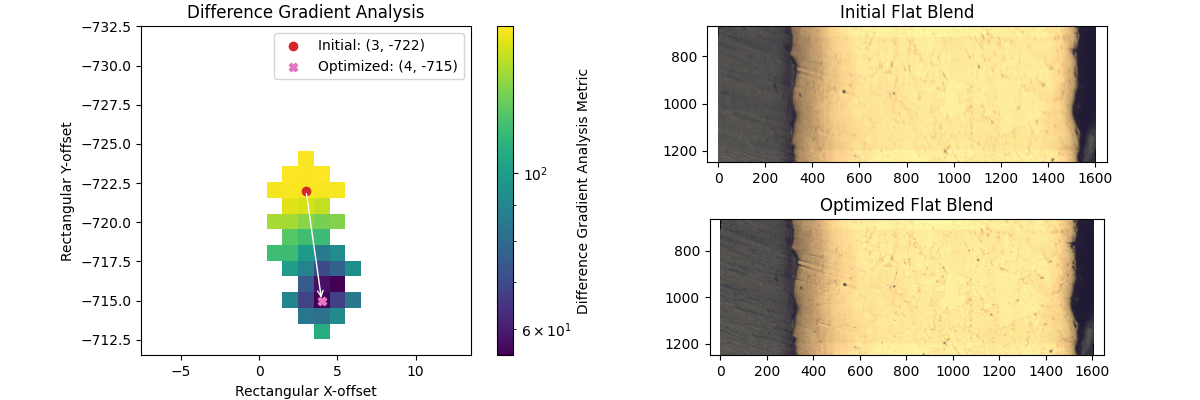

In [22]:
dga.plot_grid_difference_gradient_analysis(
        image_a=mis_project.get_image(selected_relation.get_reference()[0]),
        image_b=mis_project.get_image(selected_relation.get_reference()[1]),
        dga_grid_result=selected_dga_results,
    )
plt.show()

In [ ]:
relation_index_results=dict()
for i,relation in enumerate(mis_project.get_relations()):
    dga_results=dr.difference_gradient_analysis(
            image_a=mis_project.get_image(relation.get_reference()[0]),
            image_b=mis_project.get_image(relation.get_reference()[1]),
            relation=relation,
            strategy=strategy_local_minima_grid,
            metric=dr.metric_difference_absolute_mean,
            strategy_max_size=20,
            strategy_footprint=np.ones((7,7)),
            filter=dr.filter_rgb_gray_mean
            )
    print(i,":",relation.get_reference(),relation.get_relation('r'),"->",dga_results["optimized_offset"])
    dga.plot_grid_difference_gradient_analysis(
        image_a=mis_project.get_image(relation.get_reference()[0]),
        image_b=mis_project.get_image(relation.get_reference()[1]),
        dga_grid_result=dga_results,
    )
    plt.show()

In [ ]:
dga_results["grid"][0]

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

# Combining phase correlation with local minimization

In [ ]:
plt.close('all')
build_summary=list()
# for full_relation in mis_project.get_relations():
for full_relation in mis_project.get_relations()[0:5]:
# for full_relation in [mis_project.get_relations()[11]]:
    print(full_relation.get_reference())
    optimized_offset=dr.difference_gradient_analysis(
            image_a=mis_project.get_image(full_relation.get_reference()[0]),
            image_b=mis_project.get_image(full_relation.get_reference()[1]),
            relation=full_relation,
            strategy=dr.strategy_full_grid,
            metric=dr.metric_difference_max,
            strategy_max_size=10,
            filter=reference_filter
            )["optimized_offset"]
    start_time=timeit.default_timer()
    # full_dga_results=dr.difference_gradient_analysis(
    #         image_a=mis_project.get_image(full_relation.get_reference()[0]),
    #         image_b=mis_project.get_image(full_relation.get_reference()[1]),
    #         relation=None,
    #         # relation=MISRelationRectangular(image_pair=full_relation.get_reference(),rectangular=optimized_relation), #optimized relation
    #         strategy=strategy_full_search_phase_cross_correlation_grid,
    #         # metric=dr.metric_difference_squared_mean,
    #         metric=lambda a,b:1-skimage.measure.pearson_corr_coeff(a,b)[0],
    #         filter=full_search_phase_filter,
    #         strategy_max_size=9
    #         )
    
    full_dga_results=dr.difference_gradient_analysis(
            image_a=mis_project.get_image(full_relation.get_reference()[0]),
            image_b=mis_project.get_image(full_relation.get_reference()[1]),
            relation=None,
            # relation=MISRelationRectangular(image_pair=full_relation.get_reference(),rectangular=optimized_relation), #optimized relation
            strategy=dr.strategy_full_search_prediction_grid,
            # metric=dr.metric_difference_squared_mean,
            metric=lambda a,b:1-skimage.measure.pearson_corr_coeff(a,b)[0],
            filter=full_search_phase_filter,
            strategy_initial_grid_number=9,
            strategy_downsample=downsample
            )
    end_time=timeit.default_timer()
    print(f"Reference Optimized: {optimized_offset} Full Search DGA Optimized: {full_dga_results["optimized_offset"]} Time: {end_time-start_time:0.1f}s")


    search_offsets=np.array(full_dga_results["offsets_searched"])
    found_offsets=full_dga_results["offsets_predicted"]
    reduced_offsets=np.asarray(full_dga_results["offsets_reduced"])
    fig, (ax)=plt.subplots(1,1,)
    fig.set_figheight(3)
    fig.set_layout_engine('constrained')
    for i,offset in enumerate(found_offsets):
        ax.annotate("", xytext=search_offsets[i], xy=offset,
                arrowprops=dict(arrowstyle="->",alpha=0.5),)
    ax.yaxis.set_inverted(True)
    ax.scatter(search_offsets[:,0],search_offsets[:,1],marker='s',c='k',alpha=0.5,label="Search Offsets",zorder=0)
    combined_scatter=plt.scatter(reduced_offsets[:,0],reduced_offsets[:,1],c=full_dga_results["offsets_metric"],label="Search Results",zorder=1)
    plt.colorbar(combined_scatter)
    ax.scatter(*np.array(optimized_offset),marker='x', c='r',zorder=10,label="Reference Optimized")#(1/downsample)*()
    ax.scatter(*full_dga_results["optimized_offset"],marker='D', facecolors='none', edgecolors='r',zorder=11,label="Phase Optimized")
    fig.legend(loc="outside right")
    ax.set_aspect(1)
    plt.show()

    build_summary.append({
        "reference":full_relation.get_reference(),
        "total_checked":len(full_dga_results["offsets_searched"]),
        "total_time":round(end_time-start_time,1),
        "reference_offset":optimized_offset,
        "optimized_offset":full_dga_results["optimized_offset"],
        "optimized_metric":round(np.nanmin(full_dga_results["offsets_metric"]),3),
        })
print(pd.DataFrame(build_summary).to_markdown())